# 00 · Start here — the datasets and how to run everything

**MecaNano · Machine Learning for Nanomechanics**

This repository teaches the machine-learning methods from *Tutorial 1* as
short, runnable notebooks. You *read the method, then run it on real
nanoindentation data.* Nothing here needs a GPU.

### What you will learn (notebook by notebook)
| # | Notebook | Method |
|---|----------|--------|
| 01 | `features_and_pca` | curve → features, standardisation, **PCA** |
| 02 | `clustering_phases` | **k-means, silhouette, GMM, HDBSCAN** → phase map |
| 03 | `supervised_trees_rf_shap` | **decision tree → random forest → boosting**, SMOTE, **SHAP** |
| 04 | `curve_as_image_cnn` | **GASF** (curve→image) + a small **CNN** |
| 05 | `autoencoder_latent_space` | **autoencoder** and the **latent space** |
| 06 | `correlative_registration` | aligning two maps, agreement & confusion |
| 10–13 | refreshed classics | MNIST CNN, pop-in, regression, YOLO (optional) |

### How to run
```bash
pip install -r requirements.txt      # or: conda env create -f environment.yml
jupyter lab
```
Then open the notebooks in order. Each is self-contained and takes < 2 min.

### The data (all non-proprietary — see `data/README.md`)
- **Al–Cu eutectic HSNM maps** — 40 000 indents, two phases (CC BY 4.0).
- **AFM-collocated grid** — a small, fast ~800-indent grid with full curves.
- **Load–depth curves** — raw indentation curves for the deep-learning parts.
- **MNIST** — only for the classic CNN warm-up (notebook 10).

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


## 1 · An HSNM property map (Al–Cu eutectic)
A high-speed map is one *load–depth curve per pixel*. Reduced to hardness *H* and modulus *E*, it already shows the two phases: a soft Al-rich matrix and a hard Al₂Cu intermetallic.

In [2]:
df = mm.load_map("alcu_2um")
print(f"{len(df):,} indents · columns: {list(df.columns)}")
df[["H","E","HE"]].describe().round(2)

40,000 indents · columns: ['Index', 'Load', 'Depth', 'H', 'E', 'HE', 'X', 'Y', 'Z Position']


,H,E,HE
count,40000.00,40000.00,40000.00
mean,3.98,88.45,0.04
std,1.71,14.04,0.01
min,0.22,12.97,0.01
25%,2.50,78.01,0.03
50%,4.43,89.92,0.05
75%,5.26,98.65,0.05
max,9.28,161.98,0.15


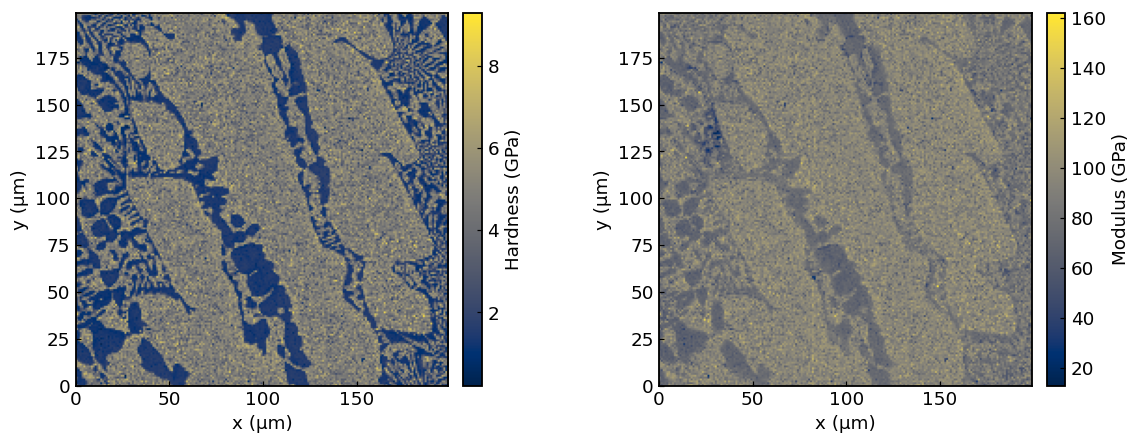

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, v, lab in zip(ax, ["H","E"], ["Hardness (GPa)","Modulus (GPa)"]):
    g, ext = mm.map_to_grid(df, v)
    mm.plot_map(g, ext, ax=a, label=lab)
fig.tight_layout()

The hardness map is bimodal — a strong hint that *two phases* are present. Every method that follows is really a way of turning that intuition into a defensible, quantitative phase map.

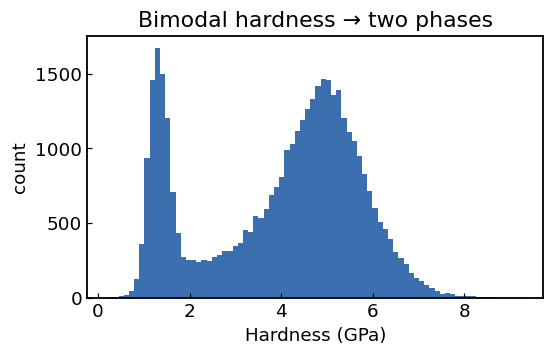

In [4]:
fig, ax = plt.subplots(figsize=(5.2,3.4))
ax.hist(df["H"], bins=80, color="#3b6fb0"); ax.set_xlabel("Hardness (GPa)")
ax.set_ylabel("count"); ax.set_title("Bimodal hardness → two phases"); fig.tight_layout()

## 2 · A small, fast grid (AFM-collocated)
When you just want something that runs in seconds, use the AFM grid. It carries the same information — scalars **and** the depth-resolved curves.

arrays: ['X', 'Y', 'H', 'E', 'S2P', 'phase_angle', 'depth_nm', 'H_curve', 'E_curve', 'load_mN', 'pitch_um', 'HE']
828 indents · curve depth axis: 0–80 nm (64 pts)


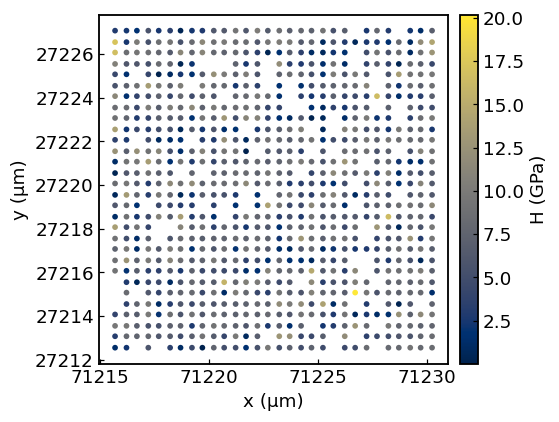

In [5]:
afm = mm.load_afm_grid()
print("arrays:", list(afm.keys()))
print(f"{afm['H'].size} indents · curve depth axis: {afm['depth_nm'][0]:.0f}–{afm['depth_nm'][-1]:.0f} nm ({afm['depth_nm'].size} pts)")
fig, ax = plt.subplots(figsize=(5,4))
mm.scatter_xy(afm["X"], afm["Y"], afm["H"], ax=ax, cmap="cividis", s=14, label="H (GPa)"); fig.tight_layout()

## 3 · Raw load–depth curves
The deep-learning notebooks work from the *whole curve*, not a single number. Here are a few.

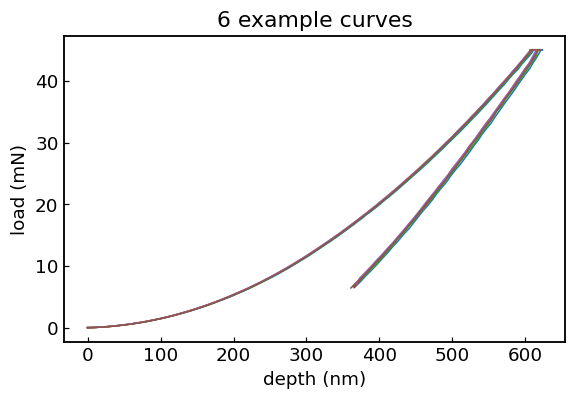

In [6]:
curves = mm.load_curves(6)
fig, ax = plt.subplots(figsize=(5.4,3.8))
for d,p in curves: ax.plot(d, p, lw=1)
ax.set_xlabel("depth (nm)"); ax.set_ylabel("load (mN)")
ax.set_title(f"{len(curves)} example curves"); fig.tight_layout()

## You are ready

Open **`01_features_and_pca.ipynb`** next.

> Tip: every notebook starts with the same setup cell and only uses the helper
> functions in `src/mecanano_ml/` for loading and plotting — so you can always
> see exactly which *machine-learning* step is being taught.